<a href="https://colab.research.google.com/github/RuchiKalkandha/Vision-Transformers/blob/main/Nanovlmcodingpart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Imports

In [ ]:
import math, random
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

##Variables

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 32
EMBED_DIM = 64
ATTENTION_HEADS = 4
BATCH_SIZE = 12
EPOCHS = 10
LR = 3e-4
TEMPERATURE = 0.07

##Synthetic dataset properties

In [ ]:
colors = ['red','green','blue','yellow','purple','orange', 'pink', 'brown', 'gray']
shapes = ['square','circle','triangle']
positions = ['left','center','right', 'top', 'bottom', 'top-left', 'top-right', 'bottom-left', 'bottom-right']

##Drawing image shapes

In [ ]:
def draw_sample(color, shape, position, img_size = IMG_SIZE):
  img = Image.new('RGB', (img_size, img_size), 'white')
  draw = ImageDraw.Draw(img)

  margin = 6
  h = w = img_size - 2*margin

  # Calculate x coordinates
  if 'left' in position:
      x0 = margin
      x1 = margin + w // 2
  elif 'top-left' in position:
      x0 = margin
      x1 = margin + w // 2
  elif 'bottom-left' in position:
      x0 = margin
      x1 = margin + w // 2
  elif 'right' in position:
      x0 = margin + w // 2
      x1 = img_size - margin
  elif 'top-right' in position:
      x0 = margin + w // 2
      x1 = img_size - margin
  elif 'bottom-right' in position:
      x0 = margin + w // 2
      x1 = img_size - margin
  else: # center or vertical positions
      x0 = margin + w // 4
      x1 = margin + 3 * w // 4

  # Calculate y coordinates
  if 'top' in position:
      y0 = margin
      y1 = margin + h // 2
  elif 'top-left' in position:
      y0 = margin
      y1 = margin + h // 2
  elif 'top-right' in position:
      y0 = margin
      y1 = margin + h // 2
  elif 'bottom' in position:
      y0 = margin + h // 2
      y1 = img_size - margin
  elif 'bottom-left' in position:
      y0 = margin + h // 2
      y1 = img_size - margin
  elif 'bottom-right' in position:
      y0 = margin + h // 2
      y1 = img_size - margin
  else: # center or horizontal positions
      y0 = margin + h // 4
      y1 = margin + 3 * h // 4

  if shape=='square':
      draw.rectangle([x0,y0,x1,y1], fill=color, outline='black')
  elif shape=='circle':
      draw.ellipse([x0,y0,x1,y1], fill=color, outline='black')
  else:  # triangle
      draw.polygon([((x1+x0)//2, y0), (x0, y1), (x1, y1)], fill=color, outline='black')
  return img

##Class for building our dataset

In [ ]:
class ShapesDataset():
  def __init__(self):
    self.images = []
    self.captions = []

    for c in colors:
      for s in shapes:
        for p in positions:
          img = draw_sample(c, s, p)
          cap = f"{c} {s} {p}"

          self.images.append(torch.from_numpy(np.asarray(img)).permute(2,0,1).float()/255.0)
          self.captions.append(cap)

    self.vocab, self.word2idx = self.build_vocab(self.captions)

  def build_vocab(self, texts):
    words = sorted({w for t in texts for w in t.split()})
    vocab = ['[CLS]'] + words
    w2i = {w:i for i,w in enumerate(vocab)}
    return vocab, w2i

  def __len__(self): return len(self.images)

  def encode_text(self, text):
    toks = [self.word2idx['[CLS]']] + [self.word2idx[w] for w in text.split()]
    return torch.tensor(toks, dtype=torch.long)

  def __getitem__(self,idx):
    return self.images[idx], self.encode_text(self.captions[idx])

##Create the full dataset

In [ ]:
full_ds = ShapesDataset()
VOCAB_SIZE = len(full_ds.vocab)
print(VOCAB_SIZE)
print(full_ds.vocab)

22
['[CLS]', 'blue', 'bottom', 'bottom-left', 'bottom-right', 'brown', 'center', 'circle', 'gray', 'green', 'left', 'orange', 'pink', 'purple', 'red', 'right', 'square', 'top', 'top-left', 'top-right', 'triangle', 'yellow']


##Train-val data creation

In [ ]:
train_size = int(0.8*len(full_ds))
val_size = len(full_ds) - train_size
train_ds, val_ds = torch.utils.data.random_split(full_ds, [train_size, val_size])

print(len(train_ds), len(val_ds))

194 49


##Dataloader

In [ ]:
train_loader = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_ds, batch_size = BATCH_SIZE, shuffle = False)

#Display a sample data point

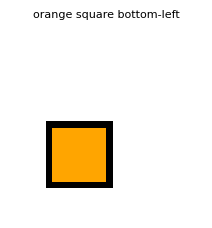

In [ ]:
imgs, encoded_caps = next(iter(train_loader))
idx = random.randint(0, len(imgs) - 1)
img = (imgs[idx].permute(1, 2, 0).numpy() * 255).astype(np.uint8) # Convert to displayable image

# Decode the caption
caption_tokens = encoded_caps[idx].tolist()
caption = " ".join([full_ds.vocab[token] for token in caption_tokens if token in range(len(full_ds.vocab))])
# Remove the [CLS] token from the displayed caption
caption = caption.replace('[CLS] ', '')


plt.figure(figsize=(2.5, 2.5))
plt.imshow(img)
plt.title(caption, fontsize=8)
plt.axis('off')
plt.show()

##Image Encoder

In [ ]:
class ImageEncoder(nn.Module):
  def __init__(self, embed_dim = EMBED_DIM):
    super().__init__()
    self.convolutions = nn.Sequential(
        nn.Conv2d(3,32,3,2,1),
        nn.ReLU(),
        nn.Conv2d(32,64,3,2,1),
        nn.ReLU(),
        nn.Conv2d(64,128,3,2,1),
        nn.ReLU(),
        nn.Conv2d(128,256,3,2,1),
        nn.ReLU(),
    )

    self.projection = nn.Linear(256, embed_dim)
    self.layernorm1 = nn.LayerNorm(embed_dim)

  def forward(self, x):
    x = self.convolutions(x)
    x = x.mean(dim=[2,3])
    x = self.projection(x)
    x = F.normalize(self.layernorm1(x), dim=-1)
    return x

##Text Encoder

In [ ]:
class TextEncoder(nn.Module):
  def __init__(self,embed_dim = EMBED_DIM, num_heads = ATTENTION_HEADS, vocab_size = VOCAB_SIZE, context_window = 4):
    super().__init__()
    self.token_embedding =  nn.Embedding(vocab_size, embed_dim)
    self.position_embedding = nn.Embedding(context_window,embed_dim)
    self.mha = nn.MultiheadAttention(embed_dim, num_heads, batch_first = True)
    self.projection = nn.Linear(embed_dim, embed_dim)
    self.norm = nn.LayerNorm(embed_dim)

  def forward(self, toks):
    N, L = toks.shape
    position_emb_ids = torch.arange(L, device = toks.device).unsqueeze(0).expand(N,L)
    position_embedding_vectors = self.position_embedding(position_emb_ids)
    token_embedding_vectors = self.token_embedding(toks)
    x = token_embedding_vectors + position_embedding_vectors
    x = self.mha(x, x, x)[0]
    x = x[:,0]
    x = self.projection(x)
    x = F.normalize(self.norm(x),dim=-1)
    return x

#CLIP loss

In [ ]:
def clip_loss(img_emb, txt_emb, temperature = TEMPERATURE):
  logits = img_emb @ txt_emb.T / temperature
  targets = torch.arange(img_emb.size(0), device = img_emb.device)
  loss_i = F.cross_entropy(logits, targets)
  loss_t = F.cross_entropy(logits.T, targets)
  return((loss_i + loss_t)/2.0)

#Model, data, optimizer

In [ ]:
img_enc = ImageEncoder().to(device)
txt_enc = TextEncoder().to(device)
params = list(img_enc.parameters()) + list(txt_enc.parameters())
optimizer = torch.optim.AdamW(params, lr = LR)

In [ ]:
def show_image(t, title=None):
    img = (t.permute(1,2,0).numpy()*255).astype(np.uint8)
    plt.figure(figsize=(2.2,2.2))
    plt.axis('off')
    if title: plt.title(title, fontsize=8)
    plt.imshow(img); plt.show()

In [ ]:
# @title
img_enc.eval(); txt_enc.eval()

with torch.no_grad():
    # Select a random index
    random_idx = random.randrange(len(full_ds))
    sample_img, sample_toks, sample_cap = full_ds[random_idx]
    sample_img = sample_img.unsqueeze(0).to(device)
    sample_toks = sample_toks.unsqueeze(0).to(device)
    pre_train_img_emb = img_enc(sample_img).squeeze(0).cpu().numpy()
    pre_train_txt_emb = txt_enc(sample_toks).squeeze(0).cpu().numpy()

# Display the sample image and caption
print(f"Sample image and caption for embeddings visualization: '{sample_cap}'")
show_image(sample_img.squeeze(0).cpu())

# Function to visualize embeddings (simplified)
def plot_embedding(embedding, title):
    plt.figure(figsize=(8, 1))
    plt.imshow(embedding.reshape(1, -1), aspect='auto', cmap='viridis')
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_embedding(pre_train_img_emb, "Pre-Training Image Embedding")
plot_embedding(pre_train_txt_emb, "Pre-Training Text Embedding")

ValueError: not enough values to unpack (expected 3, got 2)